In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.special import expit
from scipy.optimize import minimize, linprog
import sys
# from utils_3 import leaderboard_dist

## 1. Define Voter Utility Distributions
Create functions to sample `m` candidates and `n` voters using different distributions, specifically implementing independent standard normal distributions and beta distributions.

In [15]:

def sample_utilities_0_1(n_voters, m_candidates, seed=None):
    rng = np.random.default_rng(seed)
    return rng.uniform(0, 1, size=(n_voters, m_candidates))

def sample_utilities_normal(n_voters, m_candidates, seed=None):
    rng = np.random.default_rng(seed)
    return rng.standard_normal((n_voters, m_candidates))

def sample_utilities_beta(n_voters, m_candidates, a=2, b=5, seed=None):
    rng = np.random.default_rng(seed)
    return rng.beta(a, b, size=(n_voters, m_candidates))

## 2. Implement Sampling Distribution Classes
Define a configurable class to represent the sampling distribution $\mu(\{x,y\} | x)$, allowing switching between independent uniform sampling and correlated sampling distributions.

In [16]:
class SamplingDistribution:
    def __init__(self, n_candidates, method="uniform", utilities=None, beta=1.0, voter_dist=None, **kwargs):
        self.M = n_candidates
        self.method = method
        self.utilities = utilities
        self.beta = beta
        self.voter_dist = voter_dist
        self.kwargs = kwargs
        
        if self.method == "borda_correlated":
            self._compute_borda_probs()
            
    def _compute_borda_probs(self):
        # TODO: work in progress
        # We need utilities and beta to compute the BT win rates
        if self.utilities is None:
            raise ValueError("utilities must be provided for borda_correlated")
            
        V, C = self.utilities.shape
        vd = self.voter_dist if self.voter_dist is not None else np.ones(V, dtype=float) / V
        
        P_inf = np.zeros((C, C), dtype=float)
        for v, u in enumerate(self.utilities):
            diffs = u[:, None] - u[None, :]
            P_inf += vd[v] * expit(self.beta * diffs)
        np.fill_diagonal(P_inf, 0.5)
        
        S = self.kwargs.get("S", 1000)
        T = self.kwargs.get("T", 10)
        
        probs = np.ones(self.M) / self.M
        wins = np.zeros(self.M)
        
        for t in range(1, T + 1):
            xs = np.random.choice(self.M, size=S, p=probs)
            ys = np.random.choice(self.M, size=S, p=probs)
            
            valid = xs != ys
            xs = xs[valid]
            ys = ys[valid]
            
            if len(xs) > 0:
                p_win = P_inf[xs, ys]
                won = np.random.binomial(1, p_win)
                
                # Fast accumulation via bincount
                wins_x = np.bincount(xs[won == 1], minlength=self.M)
                wins_y = np.bincount(ys[won == 0], minlength=self.M)
                wins += wins_x + wins_y
                
            # Construct leaderboard (pi)
            order = np.argsort(-wins)
            ranks = np.empty_like(order)
            ranks[order] = np.arange(1, self.M + 1)
            
            # probs proportional to probs_t * 1 / (pi)^t
            probs = probs * (1.0 / (ranks ** t))
            if probs.sum() > 0:
                probs = probs / probs.sum()
            else:
                probs = np.ones(self.M) / self.M
                
        self.borda_probs = probs
        
    def get_conditional_probs(self, x, remaining_candidates=None):
        """
        Returns mu({x,y} | x) for all y in remaining_candidates.
        If remaining_candidates is None, assumes all candidates.
        """
        if remaining_candidates is None:
            remaining_candidates = np.arange(self.M)
            
        rem_list = list(remaining_candidates)
        if x not in rem_list:
            raise ValueError(f"Candidate {x} not in remaining candidates.")
            
        R = len(remaining_candidates)
        probs = np.zeros(self.M)
        
        if R <= 1:
            return probs
            
        if self.method == "uniform":
            # Uniform over all y != x
            val = 1.0 / (R - 1)
            for y in remaining_candidates:
                if y != x:
                    probs[y] = val
        
        elif self.method == "beta":
            # Use Beta PDF values on a regular grid, then normalize
            alpha = self.kwargs.get("alpha", 1.0)
            beta_param = self.kwargs.get("beta", 1.0)

            grid = np.linspace(0.0, 1.0, self.M + 2)[1:-1]
            weights = np.zeros(self.M)

            for y in remaining_candidates:
                if y != x:
                    t = grid[y]
                    weights[y] = (t ** (alpha - 1.0)) * ((1.0 - t) ** (beta_param - 1.0))

            total = weights.sum()
            if total > 0:
                probs = weights / total
            
        elif self.method == "basic_correlated":
            # E.g. candidates with closer index are more likely to be compared
            weights = np.zeros(self.M)
            for y in remaining_candidates:
                if y != x:
                    dist = abs(x - y)
                    weights[y] = 1.0 / (dist + 1.0)
            probs = weights / weights.sum()
            
        elif self.method == "borda_correlated":
            # TODO: work in progress
            # the marginal probability of y given x is just proportional to borda_probs[y]
            for y in remaining_candidates:
                if y != x:
                    probs[y] = self.borda_probs[y]
            if probs.sum() > 0:
                probs /= probs.sum()
            
        else:
            raise NotImplementedError(f"Method {self.method} not implemented.")
            
        return probs

    def get_conditional_probs_matrix(self, remaining):
        """
        Vectorised version of `get_conditional_probs`.

        Returns an (R, R) matrix where row i contains
            mu({remaining[i], remaining[j]} | remaining[i])
        for each j, with the diagonal forced to 0. This avoids the O(R)
        Python loop overhead of calling `get_conditional_probs` once per
        candidate.
        """
        rem = np.asarray(remaining)
        R = rem.shape[0]
        if R <= 1:
            return np.zeros((R, R), dtype=float)

        if self.method == "uniform":
            mat = np.full((R, R), 1.0 / (R - 1), dtype=float)
            np.fill_diagonal(mat, 0.0)
            return mat

        if self.method == "beta":
            alpha = self.kwargs.get("alpha", 1.0)
            beta_param = self.kwargs.get("beta", 1.0)
            grid = np.linspace(0.0, 1.0, self.M + 2)[1:-1]
            w_full = (grid ** (alpha - 1.0)) * ((1.0 - grid) ** (beta_param - 1.0))
            w = w_full[rem]                                # (R,)
            mat = np.broadcast_to(w, (R, R)).copy()        # mat[i, j] = w[j]
            np.fill_diagonal(mat, 0.0)
            row_sum = mat.sum(axis=1, keepdims=True)
            row_sum = np.where(row_sum > 0, row_sum, 1.0)
            return mat / row_sum

        if self.method == "basic_correlated":
            diff = np.abs(rem[:, None] - rem[None, :]).astype(float)
            w = 1.0 / (diff + 1.0)
            np.fill_diagonal(w, 0.0)
            row_sum = w.sum(axis=1, keepdims=True)
            row_sum = np.where(row_sum > 0, row_sum, 1.0)
            return w / row_sum

        if self.method == "borda_correlated":
            # Build mat[i, j] = borda_probs[remaining[j]] for j != i directly to
            # avoid catastrophic cancellation when one borda_prob dominates.
            bp = self.borda_probs[rem]                     # (R,)
            mat = np.broadcast_to(bp, (R, R)).copy()
            np.fill_diagonal(mat, 0.0)
            row_sum = mat.sum(axis=1, keepdims=True)
            row_sum = np.where(row_sum > 0, row_sum, 1.0)
            return mat / row_sum

        # Generic fallback: build column-by-column from the scalar API.
        mat = np.zeros((R, R), dtype=float)
        for ri, i in enumerate(rem):
            probs = self.get_conditional_probs(int(i), list(rem))
            mat[ri] = probs[rem]
        np.fill_diagonal(mat, 0.0)
        return mat

## 4. Calculate Population Win-Rate Matrix
Compute the pairwise win-probabilities $p(x > y)$ using the Bradley-Terry model in the infinite-sample limit by averaging the sigmoid of utility differences over all voters.

In [17]:
def compute_win_rate_matrix(utilities, voter_dist=None, beta=1.0):
    """
    Computes P[i,j] = p(i > j) using a Bradley-Terry model in the
    infinite-sample limit.

    Fully vectorised: avoids the per-voter Python loop. For very large
    V*C^2 we fall back to a chunked computation to keep peak memory
    bounded; for typical sizes this is a single einsum.
    """
    V, C = utilities.shape
    if voter_dist is None:
        voter_dist = np.ones(V, dtype=float) / V

    # Memory budget (in number of floats): ~6e7 ~= 480MB at float64.
    # If V*C*C exceeds this, chunk over voters.
    chunk = max(1, int(6e7 // max(C * C, 1)))
    if V <= chunk:
        diffs = utilities[:, :, None] - utilities[:, None, :]  # (V, C, C)
        P = np.einsum('v,vij->ij', voter_dist, expit(beta * diffs))
    else:
        P = np.zeros((C, C), dtype=float)
        for s in range(0, V, chunk):
            e = min(s + chunk, V)
            diffs = utilities[s:e, :, None] - utilities[s:e, None, :]
            P += np.einsum('v,vij->ij', voter_dist[s:e], expit(beta * diffs))

    np.fill_diagonal(P, 0.5)
    return P


def compute_win_rate_matrices_batch(utilities, voter_dist=None, betas=None):
    """
    Vectorised computation of P[b,i,j] across multiple betas in one pass.

    Parameters
    ----------
    utilities : (V, C) array
    voter_dist : (V,) array or None (uniform)
    betas : iterable of floats. Returns shape (B, C, C).
    """
    V, C = utilities.shape
    if voter_dist is None:
        voter_dist = np.ones(V, dtype=float) / V
    betas = np.asarray(list(betas), dtype=float)
    B = betas.shape[0]

    diffs = utilities[:, :, None] - utilities[:, None, :]  # (V, C, C)
    # Memory budget for B*V*C^2; fall back to per-beta if too large.
    if B * V * C * C <= 6e7:
        P_pv = expit(betas[:, None, None, None] * diffs[None, :, :, :])  # (B,V,C,C)
        P = np.einsum('v,bvij->bij', voter_dist, P_pv)
    else:
        P = np.empty((B, C, C), dtype=float)
        for b_idx, b in enumerate(betas):
            P[b_idx] = np.einsum('v,vij->ij', voter_dist, expit(b * diffs))

    diag_idx = np.arange(C)
    P[:, diag_idx, diag_idx] = 0.5
    return P


def compute_win_rate_matrices_full_batch(utilities_batch, voter_dist=None,
                                         betas=None, backend="auto"):
    """
    Compute P[s, b, i, j] for each (seed, beta) pair in one go.

    Parameters
    ----------
    utilities_batch : (S, V, C) array of utilities (one (V, C) profile per seed).
    voter_dist : (V,) array or None (uniform).
    betas : iterable of B floats.
    backend : 'numpy', 'torch' or 'auto'. With 'auto', uses torch + GPU when
        the problem is large enough to amortise the device transfer; otherwise
        falls back to a vectorised numpy path.

    Returns
    -------
    P : (S, B, C, C) numpy array. The diagonals are forced to 0.5.
    """
    utilities_batch = np.asarray(utilities_batch, dtype=np.float32)
    if utilities_batch.ndim == 2:
        utilities_batch = utilities_batch[None, ...]

    S, V, C = utilities_batch.shape
    betas = np.asarray(list(betas), dtype=np.float32)
    B = betas.shape[0]
    if voter_dist is None:
        voter_dist = np.ones(V, dtype=np.float32) / V
    voter_dist = np.asarray(voter_dist, dtype=np.float32)

    use_torch = False
    if backend in ("torch", "auto"):
        try:
            import torch  # type: ignore
            if backend == "torch":
                use_torch = True
            else:
                # Heuristic: only use GPU when there's enough work to make the
                # H2D/D2H transfer worthwhile.
                use_torch = (
                    torch.cuda.is_available()
                    and (S * B * V * C * C >= 5e7)
                )
        except Exception:
            use_torch = False

    if use_torch:
        import torch  # type: ignore
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        u = torch.from_numpy(utilities_batch).to(device)            # (S, V, C)
        vd = torch.from_numpy(voter_dist).to(device)                 # (V,)
        bs = torch.from_numpy(betas).to(device)                      # (B,)
        # diffs[s, v, i, j] = u[s, v, i] - u[s, v, j]
        diffs = u.unsqueeze(-1) - u.unsqueeze(-2)                    # (S, V, C, C)
        # P_pv[s, b, v, i, j] = sigmoid(bs[b] * diffs[s, v, i, j])
        scaled = bs[None, :, None, None, None] * diffs[:, None, :, :, :]
        P_pv = torch.sigmoid(scaled)                                  # (S, B, V, C, C)
        # weighted sum over voters
        P_t = torch.einsum("v,sbvij->sbij", vd, P_pv)
        diag = torch.arange(C, device=device)
        P_t[:, :, diag, diag] = 0.5
        return P_t.cpu().numpy().astype(np.float64)

    # Numpy path: chunk over seeds when memory is tight.
    diffs = utilities_batch[:, :, :, None] - utilities_batch[:, :, None, :]  # (S, V, C, C)
    # Approximate memory of the (S, B, V, C, C) intermediate (float32).
    bytes_per = S * B * V * C * C * 4
    chunk_seeds = max(1, int(2e8 // max(B * V * C * C * 4, 1)))
    if S * B * V * C * C <= 5e7:
        scaled = betas[None, :, None, None, None] * diffs[:, None, :, :, :]
        P_pv = expit(scaled)                                         # (S, B, V, C, C)
        P = np.einsum("v,sbvij->sbij", voter_dist, P_pv)
    else:
        P = np.empty((S, B, C, C), dtype=np.float64)
        for s in range(0, S, chunk_seeds):
            e = min(s + chunk_seeds, S)
            d_chunk = diffs[s:e]                                     # (s', V, C, C)
            scaled = betas[None, :, None, None, None] * d_chunk[:, None, :, :, :]
            P_pv = expit(scaled)
            P[s:e] = np.einsum("v,sbvij->sbij", voter_dist, P_pv)

    diag_idx = np.arange(C)
    P[:, :, diag_idx, diag_idx] = 0.5
    return P

## 5. Implement Modified Borda Count
Write a function to compute the modified Borda count for each candidate using the formula $BC(x) = \sum_{y}(\mu(\{x,y\} | x) p(x > y))$.

In [18]:
def modified_borda(P, sampling_dist, remaining=None):
    """
    Computes BC(x) = sum_y mu({x,y}|x) P(x > y)

    Fully vectorised: O(R^2) numpy operations instead of nested Python loops.
    """
    R = P.shape[0]
    if remaining is None:
        remaining = list(range(R))

    rem = np.asarray(remaining)
    P_rem = P[np.ix_(rem, rem)]
    mu = sampling_dist.get_conditional_probs_matrix(remaining)
    bc_rem = np.einsum('ij,ij->i', mu, P_rem)

    scores = np.zeros(R)
    scores[rem] = bc_rem
    return scores


def borda_ranking(P, sampling_dist):
    scores = modified_borda(P, sampling_dist)
    return np.argsort(-scores)

## 6. Implement Borda with Peeling
Implement a peeling mechanism that iteratively calculates $BC(x)$ on the remaining candidates, selects the candidate with the highest score, and removes them from the candidate pool to form a ranking.

In [19]:
def resample_P_on_remaining(P_inf, remaining, n_samples=None):
    """
    Helper to dynamically re-sample the empirical winrate matrix on a subset
    of candidates. With `n_samples=None` we short-circuit and return `P_inf`
    directly (downstream consumers only ever index at remaining positions).
    For finite `n_samples` we vectorise the per-pair binomial sampling.
    """
    if n_samples is None or n_samples == np.inf:
        return P_inf

    rem = np.asarray(remaining)
    R = rem.shape[0]
    if R < 2:
        curr_P = np.zeros_like(P_inf)
        np.fill_diagonal(curr_P, 0.5)
        return curr_P

    P_rem = P_inf[np.ix_(rem, rem)]
    n_pairs = R * (R - 1) // 2
    samples_per_pair = max(1, n_samples // n_pairs)

    iu, ju = np.triu_indices(R, k=1)
    p_vals = P_rem[iu, ju]
    wins = np.random.binomial(samples_per_pair, p_vals)
    win_rates = wins / samples_per_pair

    sub = np.full((R, R), 0.5, dtype=float)
    sub[iu, ju] = win_rates
    sub[ju, iu] = 1.0 - win_rates

    curr_P = np.zeros_like(P_inf)
    curr_P[np.ix_(rem, rem)] = sub
    return curr_P


def borda_peeling(P_inf, sampling_dist, n_samples=None):
    R = P_inf.shape[0]
    remaining = list(range(R))
    ranking = []

    while remaining:
        curr_P = resample_P_on_remaining(P_inf, remaining, n_samples)

        rem = np.asarray(remaining)
        P_rem = curr_P[np.ix_(rem, rem)]
        mu = sampling_dist.get_conditional_probs_matrix(remaining)
        local_scores = np.einsum('ij,ij->i', mu, P_rem)

        best_idx_local = int(np.argmax(local_scores))
        best_candidate = remaining[best_idx_local]

        ranking.append(best_candidate)
        remaining.pop(best_idx_local)

    return np.array(ranking)



In [20]:
example_utilities = sample_utilities_0_1(30, 30, seed=42)
example_P = compute_win_rate_matrix(example_utilities)
example_dist = SamplingDistribution(n_candidates=30, method="uniform", utilities=example_utilities, beta=1.0)
rank1 = borda_peeling(example_P, example_dist)

In [21]:
rank1

array([22, 26,  9,  1, 29, 20,  5, 11, 27,  0,  6, 13,  3, 21, 23, 25, 16,
       17, 12,  7, 19, 15, 24,  8, 10, 14,  4, 18, 28,  2])

Fixed weight set

Implementing ML peeling nonzero

Implementing expectation over ML distortion from probabilities of leaderboards

In [22]:
def sample_win_rate_matrix(P, n_samples):
    """
    Given an exact win-rate matrix P, sample a finite number of pairwise comparisons
    and return an empirical win-rate matrix. Vectorised version: a single call
    to `np.random.binomial` over the upper triangle.
    """
    if n_samples is None or n_samples == np.inf:
        return P
    C = P.shape[0]
    if C < 2:
        out = np.zeros_like(P)
        np.fill_diagonal(out, 0.5)
        return out

    iu, ju = np.triu_indices(C, k=1)
    n_pairs = iu.shape[0]
    samples_per_pair = max(1, n_samples // n_pairs)
    p_vals = P[iu, ju]
    wins = np.random.binomial(samples_per_pair, p_vals)
    win_rates = wins / samples_per_pair

    emp_P = np.full((C, C), 0.5, dtype=float)
    emp_P[iu, ju] = win_rates
    emp_P[ju, iu] = 1.0 - win_rates
    return emp_P


def _copeland_sign(P_block, tie_tol):
    """+1 / 0 / -1 sign matrix for pairwise comparisons with a tolerance."""
    sign = np.where(
        P_block > 0.5 + tie_tol, 1.0,
        np.where(P_block < 0.5 - tie_tol, -1.0, 0.0),
    )
    np.fill_diagonal(sign, 0.0)
    return sign


def copeland_ranking(P, sampling_dist, tie_tol=1e-12):
    R = P.shape[0]
    mu = sampling_dist.get_conditional_probs_matrix(list(range(R)))
    sign = _copeland_sign(P, tie_tol)
    scores = np.einsum('ij,ij->i', mu, sign)
    return np.argsort(-scores)


def copeland_peeling(P_inf, sampling_dist, n_samples=None, tie_tol=1e-12):
    R = P_inf.shape[0]
    remaining = list(range(R))
    ranking = []

    while remaining:
        curr_P = resample_P_on_remaining(P_inf, remaining, n_samples)
        rem = np.asarray(remaining)
        P_rem = curr_P[np.ix_(rem, rem)]
        mu = sampling_dist.get_conditional_probs_matrix(remaining)
        sign = _copeland_sign(P_rem, tie_tol)
        local_scores = np.einsum('ij,ij->i', mu, sign)

        best_idx_local = int(np.argmax(local_scores))
        best_candidate = remaining[best_idx_local]

        ranking.append(best_candidate)
        remaining.pop(best_idx_local)

    return np.array(ranking)

def maximal_lottery_probs(P, sampling_dist, remaining):
    R = len(remaining)
    if R == 1:
        return np.array([1.0])

    rem = np.asarray(remaining)
    P_rem = P[np.ix_(rem, rem)]
    mu = sampling_dist.get_conditional_probs_matrix(remaining)  # (R, R), diag=0

    # margin[i, j] = mu[i, j] * P[i, j] - mu[j, i] * P[j, i]
    weighted = mu * P_rem
    margins = weighted - weighted.T
    np.fill_diagonal(margins, 0.0)

    # Fast path: if some pure strategy `i` has non-negative margin against every
    # opponent (row-min >= 0), then x = e_i is an optimal solution and we can
    # skip the LP entirely. This is the common case at moderate-to-high beta.
    row_min = margins.min(axis=1)
    pure_idx = int(np.argmax(row_min))
    if row_min[pure_idx] >= -1e-12:
        x = np.zeros(R, dtype=float)
        x[pure_idx] = 1.0
        return x

    # Solve minimax:
    # max v s.t. M^T x >= v, sum(x)=1, x >= 0
    c = np.zeros(R + 1, dtype=float)
    c[-1] = -1.0  # minimise -v

    A_ub = np.hstack((-margins.T, np.ones((R, 1), dtype=float)))
    b_ub = np.zeros(R, dtype=float)

    A_eq = np.zeros((1, R + 1), dtype=float)
    A_eq[0, :R] = 1.0
    b_eq = np.array([1.0])

    bounds = [(0.0, 1.0)] * R + [(None, None)]  # v is unbounded

    result = linprog(
        c=c,
        A_ub=A_ub,
        b_ub=b_ub,
        A_eq=A_eq,
        b_eq=b_eq,
        bounds=bounds,
        method="highs",
    )
    if not result.success:
        print("Warning: LP failed to find a solution, returning uniform distribution.")
        print("LP message:", result.message)
        return np.ones(R, dtype=float) / R

    return np.asarray(result.x[:R], dtype=float)

def maximal_lottery_ranking(P, sampling_dist, tie_tol=1e-12):
    R = P.shape[0]
    lottery = maximal_lottery_probs(P, sampling_dist, list(range(R)))
    return np.argsort(-lottery)

def maximal_lottery_peeling_max(P_inf, sampling_dist, n_samples=None):
    R = P_inf.shape[0]
    remaining = list(range(R))
    ranking = []
    
    while remaining:
        curr_P = resample_P_on_remaining(P_inf, remaining, n_samples)
        lottery = maximal_lottery_probs(curr_P, sampling_dist, remaining)
        best_idx_local = np.argmax(lottery)
        best_candidate = remaining[best_idx_local]
        
        ranking.append(best_candidate)
        remaining.remove(best_candidate)
        
    return np.array(ranking)

def maximal_lottery_peeling_sample(P_inf, sampling_dist, n_samples=None):
    R = P_inf.shape[0]
    remaining = list(range(R))
    ranking = []
    
    while remaining:
        curr_P = resample_P_on_remaining(P_inf, remaining, n_samples)
        lottery = maximal_lottery_probs(curr_P, sampling_dist, remaining)
        lottery = np.maximum(lottery, 0)
        s = np.sum(lottery)
        if s > 0:
            lottery /= s
        else:
            lottery = np.ones(len(remaining)) / len(remaining)
            
        best_idx_local = np.random.choice(len(remaining), p=lottery)
        best_candidate = remaining[best_idx_local]
        
        ranking.append(best_candidate)
        remaining.remove(best_candidate)
        
    return np.array(ranking)

def maximal_lottery_peeling_group(P_inf, sampling_dist, n_samples=None):
    R = P_inf.shape[0]
    remaining = list(range(R))
    ranking = []
    
    while remaining:
        curr_P = resample_P_on_remaining(P_inf, remaining, n_samples)
        lottery = maximal_lottery_probs(curr_P, sampling_dist, remaining)
        
        non_zero_indices = [i for i, prob in enumerate(lottery) if prob > 1e-6]
        
        group_cands = [remaining[i] for i in sorted(non_zero_indices, key=lambda idx: lottery[idx], reverse=True)]
        if not group_cands:
            group_cands = [remaining[0]]
            
        for cand in group_cands:
            ranking.append(cand)
            remaining.remove(cand)
            
    return np.array(ranking)

def ranking_distribution_pruned(candidates, get_lottery_fn):
    cache = {}

    def recurse(remaining):
        remaining_fs = frozenset(remaining)

        if len(remaining_fs) == 1:
            c = next(iter(remaining_fs))
            return {(c,): 1.0}
            
        if remaining_fs not in cache:
            cache[remaining_fs] = get_lottery_fn(list(remaining))
        ml = cache[remaining_fs]
        
        result = {}

        for i, p in enumerate(ml):
            if p <= 1e-6:
                continue
                
            c = remaining[i]
            sub_rem = list(remaining)
            sub_rem.remove(c)
            subdist = recurse(sub_rem)

            for suffix, q in subdist.items():
                result[(c,) + suffix] = p * q

        return result

    return recurse(candidates)

def expected_average_utilities(ranking_dist, avg_utilities):
    """E_{r ~ ranking_dist}[ avg_utilities[r] ] : returns a length-M array."""
    M = len(avg_utilities)
    if not ranking_dist:
        return np.zeros(M, dtype=float)

    rankings = np.asarray(list(ranking_dist.keys()), dtype=np.int64)   # (K, M)
    weights = np.asarray(list(ranking_dist.values()), dtype=float)     # (K,)
    return np.sum(weights[:, None] * avg_utilities[rankings], axis=0)

def expected_maximal_lottery_peeling(P_inf, sampling_dist, n_samples=None):
    """
    Compute the full distribution over rankings induced by repeatedly applying
    the maximal lottery on the remaining candidates and "peeling" off one
    candidate at a time according to its lottery probability.

    Returns a dict mapping ranking tuples to their probability mass under the
    ML-peeling process. Use one of the `expected_leaderboard_distortion*`
    functions to convert this distribution into a distortion value.

    NOTE: this enumerates the support of the ranking distribution, so it grows
    super-polynomially with M when the lotteries are mixed. For large M (or
    low beta) prefer `sample_expected_maximal_lottery_peeling` which is linear
    in `n_mc_samples * M`.
    """
    R = P_inf.shape[0]

    def get_lottery_fn(remaining):
        curr_P = resample_P_on_remaining(P_inf, remaining, n_samples)
        return maximal_lottery_probs(curr_P, sampling_dist, remaining)

    return ranking_distribution_pruned(list(range(R)), get_lottery_fn)


def sample_expected_maximal_lottery_peeling(
    P_inf, sampling_dist, n_mc_samples=200, n_samples=None, rng=None,
):
    """
    Monte Carlo estimate of the ML-peeling ranking distribution.

    Repeatedly simulates the ML-peeling process `n_mc_samples` times and
    returns a dict ``{ranking: 1/n_mc_samples}`` over the sampled rankings
    (collapsing duplicates and summing weights). This avoids the exponential
    enumeration in `expected_maximal_lottery_peeling` and runs in
    O(n_mc_samples * M * cost(ML)) time.

    The returned dict can be passed directly to
    `expected_leaderboard_distortion[_by_weights]`.
    """
    if rng is None:
        rng = np.random.default_rng()

    R = P_inf.shape[0]

    # Cache lotteries by remaining-set: each unique set is solved at most once
    # per call. This is a big win when n_mc_samples is large.
    lottery_cache = {}

    def get_lottery(remaining_tuple):
        if remaining_tuple not in lottery_cache:
            remaining = list(remaining_tuple)
            curr_P = resample_P_on_remaining(P_inf, remaining, n_samples)
            lot = maximal_lottery_probs(curr_P, sampling_dist, remaining)
            # LP may return tiny negatives; clean up so np.random.choice is happy.
            lot = np.clip(lot, 0.0, None)
            s = lot.sum()
            lot = lot / s if s > 0 else np.ones_like(lot) / len(lot)
            lottery_cache[remaining_tuple] = lot
        return lottery_cache[remaining_tuple]

    counts = {}
    weight = 1.0 / n_mc_samples
    for _ in range(n_mc_samples):
        remaining = list(range(R))
        ranking = []
        while remaining:
            key = tuple(sorted(remaining))
            lottery = get_lottery(key)
            # `remaining` and the lottery are aligned (lottery[i] is the prob
            # for remaining[i]).
            idx = int(rng.choice(len(remaining), p=lottery))
            ranking.append(remaining[idx])
            remaining.pop(idx)
        ranking_t = tuple(ranking)
        counts[ranking_t] = counts.get(ranking_t, 0.0) + weight

    return counts



## 7. Compute Supremum Leaderboard Distortion

In [23]:
def compute_supremum_leaderboard_distortion(ranking, true_ranking, avg_utils):
    """
    Computes supremum of leaderboard distortion over all monotonically decreasing weights.
    By identifying extreme points, this boils down to max prefix sum ratio.
    """
    ranking = np.asarray(ranking)
    true_ranking = np.asarray(true_ranking)
    
    ranking_utils = avg_utils[ranking]
    true_ranking_utils = avg_utils[true_ranking]
    
    denom_cumsum = np.cumsum(ranking_utils)
    num_cumsum = np.cumsum(true_ranking_utils)
    
    ratio = np.max(num_cumsum / denom_cumsum)
    
    return ratio

def compute_leaderboard_distortion_by_weights(ranking, true_ranking, avg_utils, weights):
    """
    Computes leaderboard distortion for a specific choice of weights.
    """
    ranking = np.asarray(ranking)
    true_ranking = np.asarray(true_ranking)
    
    ranking_utils = avg_utils[ranking]
    true_ranking_utils = avg_utils[true_ranking]
    
    weighted_ranking_score = np.sum(weights * ranking_utils)
    weighted_true_score = np.sum(weights * true_ranking_utils)
    
    if weighted_ranking_score == 0:
        return float('inf') if weighted_true_score > 0 else 1.0
    
    return weighted_true_score / weighted_ranking_score


def expected_leaderboard_distortion(ranking_dist, true_ranking, avg_utils):
    """
    Supremum-leaderboard distortion of a *random* ranking against the true
    ranking, evaluated on the expected utility profile

        E_{r ~ ranking_dist}[ avg_utils[r] ].

    This computes
        max_k  cumsum(true_utils)[k] / cumsum(E[ranking_utils])[k] ,
    i.e. the supremum leaderboard distortion of the expected ranking utility
    profile (equivalent to sup_w E[true_score(w)] / E[ranking_score(w)] over
    monotone non-increasing weights w).
    """
    true_ranking = np.asarray(true_ranking)

    ranking_utils = expected_average_utilities(ranking_dist, avg_utilities=avg_utils)
    true_ranking_utils = avg_utils[true_ranking]

    denom_cumsum = np.cumsum(ranking_utils)
    num_cumsum = np.cumsum(true_ranking_utils)

    return float(np.max(num_cumsum / denom_cumsum))


def expected_leaderboard_distortion_by_weights(ranking_dist, true_ranking, avg_utils, weights):
    """
    Weighted leaderboard distortion of a *random* ranking against the true
    ranking, using the expected utility profile in the denominator.
    """
    true_ranking = np.asarray(true_ranking)

    ranking_utils = expected_average_utilities(ranking_dist, avg_utilities=avg_utils)
    true_ranking_utils = avg_utils[true_ranking]

    weighted_ranking_score = float(np.sum(weights * ranking_utils))
    weighted_true_score = float(np.sum(weights * true_ranking_utils))

    if weighted_ranking_score == 0:
        return float('inf') if weighted_true_score > 0 else 1.0

    return weighted_true_score / weighted_ranking_score

## 8. Run Simulations and Visualize Results
Set up a simulation loop calculating the true average utility rankings, generated Borda rankings, and their respective distortions across multiple values of $\beta$ and distribution parameters, then plot the resulting distortion arrays.

In [ ]:
import concurrent.futures
from collections import defaultdict
import numpy as np

n_voters = 30
m_candidates = 30
betas = [0.1, 0.5, 1.0, 2.0, 3.0, 5.0, 10.0, 20.0, 50.0, 100.0, 200, 300, 500, 1000, 2000, 3000, 5000, 10000, 20000, 30000, 50000, 100000, 200000, 300000, 500000, 1e6]
# betas = [0.01, 0.05, 0.1, 0.2, 0.5, 1.0, 2.0, 5.0, 10.0, 20.0, 50.0, 100.0, 200.0]
n_samples_finite = None # Set to None for infinite limit
n_seeds = 128 # Number of times to run with different seeds
max_workers = 128 # Number of parallel threads/processes
# n_mc_samples_expected: number of Monte Carlo samples for ml_peeling_expected.
# Set to None to use the (exact but exponential) `expected_maximal_lottery_peeling`.
# For m_candidates >= ~12 with low-beta mixed lotteries, prefer MC (e.g. 200-1000)
# to avoid the super-polynomial blow-up.
n_mc_samples_expected = 1 if m_candidates >= 12 else None
example_weights = np.array([1.0 / (1.1**k) for k in range(m_candidates)])
methods_to_run = ['borda', 'borda_peeling', 'copeland', 'copeland_peeling', 'ml_peeling_max', 'ml_peeling_sample', 'ml_peeling_group', f'ml_peeling_expected_{n_mc_samples_expected}']
# distortion_function = lambda p, true_rank, avg_utils: compute_supremum_leaderboard_distortion(p, true_rank, avg_utils)
# expected_distortion_function = lambda dist, true_rank, avg_utils: expected_leaderboard_distortion(dist, true_rank, avg_utils)
distortion_function = lambda p, true_rank, avg_utils: compute_leaderboard_distortion_by_weights(p, true_rank, avg_utils, example_weights)
expected_distortion_function = lambda dist, true_rank, avg_utils: expected_leaderboard_distortion_by_weights(dist, true_rank, avg_utils, example_weights)
def run_sim(utilities, method, n_samples=None):
    voter_dist = np.ones(n_voters, dtype=float) / n_voters
    avg_utils = voter_dist @ utilities
    true_rank = np.argsort(-avg_utils)
    
    out = defaultdict(list)
    
    sampling_dist = SamplingDistribution(m_candidates, method=method, kwargs={"alpha": 2.0, "beta": 5.0})
    
    for b in betas:
        P_inf = compute_win_rate_matrix(utilities, voter_dist, beta=b)
        P = sample_win_rate_matrix(P_inf, n_samples)
        
        borda_rank = borda_ranking(P, sampling_dist)
        peel_rank = borda_peeling(P_inf, sampling_dist, n_samples)
        cope_rank = copeland_ranking(P, sampling_dist)
        cope_peel = copeland_peeling(P_inf, sampling_dist, n_samples)
        
        try:
            ml_p_max = maximal_lottery_peeling_max(P_inf, sampling_dist, n_samples)
            ml_dist_pmax = distortion_function(ml_p_max, true_rank, avg_utils)
        except Exception:
            ml_dist_pmax = float('nan')
            ml_p_max = np.zeros(m_candidates)
        out['ml_peeling_max'].append((ml_dist_pmax, ml_p_max))

        try:
            ml_p_samp = maximal_lottery_peeling_sample(P_inf, sampling_dist, n_samples)
            ml_dist_psamp = distortion_function(ml_p_samp, true_rank, avg_utils)
        except Exception:
            ml_dist_psamp = float('nan')
            ml_p_samp = np.zeros(m_candidates)
        out['ml_peeling_sample'].append((ml_dist_psamp, ml_p_samp))

        try:
            ml_p_group = maximal_lottery_peeling_group(P_inf, sampling_dist, n_samples)
            ml_dist_pgroup = distortion_function(ml_p_group, true_rank, avg_utils)
        except Exception:
            ml_dist_pgroup = float('nan')
            ml_p_group = np.zeros(m_candidates)
        out['ml_peeling_group'].append((ml_dist_pgroup, ml_p_group))

        try:
            if n_mc_samples_expected is None:
                ml_dist_exp = expected_maximal_lottery_peeling(P_inf, sampling_dist, n_samples)
            else:
                ml_dist_exp = sample_expected_maximal_lottery_peeling(
                    P_inf, sampling_dist,
                    n_mc_samples=n_mc_samples_expected,
                    n_samples=n_samples,
                )
            ml_dist_pexp = expected_distortion_function(ml_dist_exp, true_rank, avg_utils)
        except Exception:
            ml_dist_pexp = float('nan')
            ml_dist_exp = {}
        out[f'ml_peeling_expected_{n_mc_samples_expected}'].append((ml_dist_pexp, ml_dist_exp))
        
        out['borda'].append((distortion_function(borda_rank, true_rank, avg_utils), borda_rank))
        out['borda_peeling'].append((distortion_function(peel_rank, true_rank, avg_utils), peel_rank))
        out['copeland'].append((distortion_function(cope_rank, true_rank, avg_utils), cope_rank))
        out['copeland_peeling'].append((distortion_function(cope_peel, true_rank, avg_utils), cope_peel))

                # rand_rank = np.random.permutation(m_candidates)
        # out['random'].append(compute_supremum_leaderboard_distortion(rand_rank, true_rank, avg_utils))
        
    return out

def run_single_seed(seed):
    dist_normal = sample_utilities_normal(n_voters, m_candidates, seed=seed)
    dist_beta = sample_utilities_beta(n_voters, m_candidates, a=2, b=5, seed=seed)
    dist_unif = sample_utilities_0_1(n_voters, m_candidates, seed=seed)
    
    out_ind_norm = run_sim(dist_normal, "uniform", n_samples_finite)
    out_ind_beta = run_sim(dist_beta, "uniform", n_samples_finite)
    out_ind_unif = run_sim(dist_unif, "uniform", n_samples_finite)
    # out_ind_norm = run_sim(dist_normal, "beta", n_samples_finite)
    # out_ind_beta = run_sim(dist_beta, "beta", n_samples_finite)
    # out_ind_unif = run_sim(dist_unif, "beta", n_samples_finite)
    
    
    return {
        "independent_normal": out_ind_norm,
        "independent_beta": out_ind_beta,
        "independent_uniform": out_ind_unif
    }

def aggregate_results(seed_results):
    all_runs = {
        dist: {m: [] for m in methods_to_run} 
        for dist in ["independent_normal", "independent_beta", "independent_uniform"]
    }
    
    for res in seed_results:
        for dist, out_dict in res.items():
            for m in methods_to_run:
                all_runs[dist][m].append(out_dict[m])

    results = {}
    best_rankings = {}
    best_seeds = {}
    for dist in all_runs:
        for m in methods_to_run:
            seeds_data = all_runs[dist][m]
            num_betas = len(betas)
            
            max_dists = np.zeros(num_betas)
            worst_case_ranks = [None] * num_betas
            worst_case_seeds = [None] * num_betas
            
            for b_idx in range(num_betas):
                dists_for_b = [seeds_data[seed_idx][b_idx][0] for seed_idx in range(len(seeds_data))]
                ranks_for_b = [seeds_data[seed_idx][b_idx][1] for seed_idx in range(len(seeds_data))]
                
                valid_dists = [(val, idx) for idx, val in enumerate(dists_for_b) if not np.isnan(val)]
                if valid_dists:
                    max_val, best_idx = max(valid_dists, key=lambda x: x[0])
                    max_dists[b_idx] = max_val
                    worst_case_ranks[b_idx] = ranks_for_b[best_idx]
                    worst_case_seeds[b_idx] = best_idx
                else:
                    max_dists[b_idx] = np.nan
                    worst_case_ranks[b_idx] = None
                    worst_case_seeds[b_idx] = None
                    
            results[f"{dist}_{m}"] = max_dists
            best_rankings[f"{dist}_{m}"] = worst_case_ranks
            best_seeds[f"{dist}_{m}"] = worst_case_seeds
            
    return results, best_rankings, best_seeds

def plot_results(results):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    labels = methods_to_run
    markers = ['o', 's', '^', 'v', 'D', 'p', 'x', '*']

    dist_names = ["independent_normal", "independent_beta", "independent_uniform"]
    titles = ["Independent Normal", "Independent Beta", "Independent Uniform"]

    for i, (d_name, title) in enumerate(zip(dist_names, titles)):
        for j, m in enumerate(labels):
            print(f"Plotting {d_name} - {m} with max distortion {np.nanmax(results[f'{d_name}_{m}']):.3f}")
            axes[i].plot(betas, results[f"{d_name}_{m}"], marker=markers[j], label=m.capitalize())
        axes[i].set_title(f"{title}\n(Max over {n_seeds} seeds)")
        axes[i].set_xscale("log")
        if i == 0:
            axes[i].legend()

    plt.tight_layout()
    plt.show()

# Run simulations in parallel
print(f"Running simulations for {n_seeds} seeds using {max_workers} processes...")
with concurrent.futures.ProcessPoolExecutor(max_workers=max_workers) as executor:
    seed_results = list(executor.map(run_single_seed, range(n_seeds)))

print("Aggregating and plotting results...")
results, worst_case_rankings, worst_case_seeds = aggregate_results(seed_results)
plot_results(results)



Running simulations for 128 seeds using 128 processes...
Aggregating and plotting results...


IndexError: list index out of range

In [68]:
def sample_single_seed_utilities(seed):
    dist_normal = sample_utilities_normal(n_voters, m_candidates, seed=seed)
    dist_beta = sample_utilities_beta(n_voters, m_candidates, a=2, b=5, seed=seed)
    dist_unif = sample_utilities_0_1(n_voters, m_candidates, seed=seed)
    return {
        "independent_normal": dist_normal,
        "independent_beta": dist_beta,
        "independent_uniform": dist_unif
    }

<Axes: >

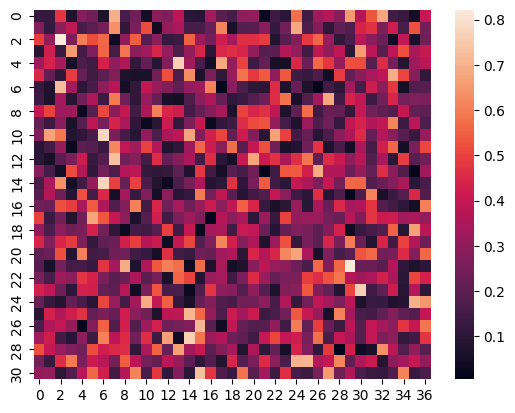

In [64]:
sns.heatmap(sample_single_seed_utilities(101)['independent_beta'])

[12 16 22  0 20 24  5 30 29 26 23 14 18  3  4  1  2  9  8 27 19  6 13 15
 17 10 11 28 25  7 21]


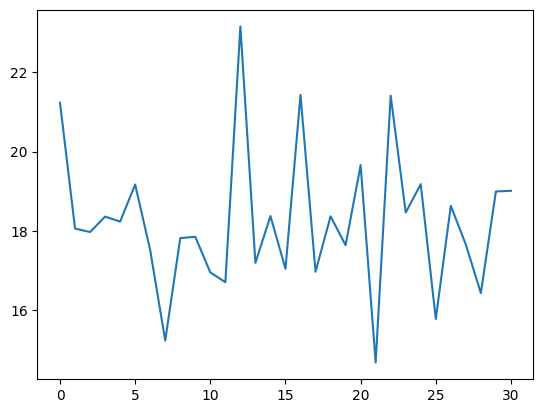

In [63]:
utility_sums = np.array([np.sum(sample_single_seed_utilities(101)['independent_uniform'][i, :]) for i in range(n_voters)])
plt.plot(utility_sums)
print(np.argsort(-utility_sums))

In [65]:
compute_win_rate_matrix(sample_single_seed_utilities(101)['independent_uniform'], beta=10000000000.0)

array([[0.5       , 0.51612903, 0.41935484, ..., 0.51612903, 0.58064516,
        0.38709677],
       [0.48387097, 0.5       , 0.51612903, ..., 0.4516129 , 0.67741935,
        0.35483871],
       [0.58064516, 0.48387097, 0.5       , ..., 0.51612903, 0.5483871 ,
        0.51612903],
       ...,
       [0.48387097, 0.5483871 , 0.48387097, ..., 0.5       , 0.5483871 ,
        0.4516129 ],
       [0.41935484, 0.32258065, 0.4516129 , ..., 0.4516129 , 0.5       ,
        0.35483871],
       [0.61290323, 0.64516129, 0.48387097, ..., 0.5483871 , 0.64516129,
        0.5       ]], shape=(37, 37))

In [62]:
worst_case_rankings['independent_uniform_borda'][20]

array([36,  6, 27, 19,  2, 21,  1, 20,  8, 22, 16, 33, 34, 18, 10, 15, 28,
        9, 31, 25, 13, 30, 12,  0,  4, 14, 24, 23, 29, 11,  3,  7, 26, 35,
        5, 17, 32])

In [61]:
worst_case_rankings['independent_uniform_borda_peeling'][20]

array([36,  6, 27, 19,  1, 20, 21,  2,  8, 22, 16, 34, 33, 10, 15, 28, 18,
       31, 13,  9, 25, 30, 14, 24,  0, 29, 12, 11,  4,  7, 23, 35,  3, 26,
       32, 17,  5])

In [60]:
worst_case_seeds

{'independent_normal_borda': [121,
  47,
  23,
  37,
  45,
  45,
  14,
  58,
  45,
  45,
  45,
  45,
  45,
  45,
  45,
  45,
  45,
  45,
  45,
  45,
  45,
  45,
  45,
  45,
  45,
  45],
 'independent_normal_borda_peeling': [69,
  22,
  14,
  2,
  13,
  13,
  69,
  61,
  45,
  45,
  45,
  45,
  45,
  20,
  20,
  16,
  16,
  16,
  16,
  16,
  16,
  16,
  16,
  16,
  16,
  16],
 'independent_normal_copeland': [99,
  22,
  102,
  14,
  14,
  14,
  37,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10],
 'independent_normal_copeland_peeling': [99,
  0,
  102,
  102,
  116,
  45,
  19,
  52,
  16,
  116,
  116,
  116,
  116,
  116,
  116,
  116,
  116,
  116,
  116,
  116,
  116,
  116,
  116,
  116,
  116,
  116],
 'independent_normal_ml_peeling_max': [99,
  22,
  102,
  101,
  23,
  89,
  61,
  10,
  10,
  97,
  101,
  101,
  101,
  16,
  37,
  16,
  58,
  16,
  72,
  72,
  72,
  72,
  72,
  72,
  72,
  72],
 'independent_norma

In [69]:
results['independent_uniform_borda']

array([1.00000014, 1.00009637, 1.00314119, 1.0047739 , 1.01826808,
       1.02740118, 1.03300225, 1.04474599, 1.07586022, 1.09548366,
       1.09548366, 1.09548366, 1.09548366, 1.09548366, 1.09548366,
       1.09548366, 1.09548366, 1.07586022, 1.07586022, 1.07586022,
       1.07586022, 1.07586022, 1.07586022, 1.07586022, 1.07586022,
       1.07586022])

In [70]:
results['independent_uniform_borda_peeling']

array([1.00000082, 1.00013317, 1.00314119, 1.00605942, 1.01826808,
       1.02740118, 1.03300225, 1.04474599, 1.07586022, 1.09548366,
       1.09548366, 1.09548366, 1.09548366, 1.09548366, 1.09548366,
       1.09548366, 1.09548366, 1.09548366, 1.09548366, 1.09548366,
       1.09548366, 1.09548366, 1.09548366, 1.09548366, 1.09548366,
       1.09548366])

In [71]:
results['independent_uniform_borda'] - results['independent_uniform_borda_peeling']

array([-6.75553570e-07, -3.68090467e-05,  0.00000000e+00, -1.28552635e-03,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00, -1.96234424e-02, -1.96234424e-02, -1.96234424e-02,
       -1.96234424e-02, -1.96234424e-02, -1.96234424e-02, -1.96234424e-02,
       -1.96234424e-02, -1.96234424e-02])

# 9. Correlated Beta - simple

Running simulations for 128 seeds using 128 processes...
Aggregating and plotting results...


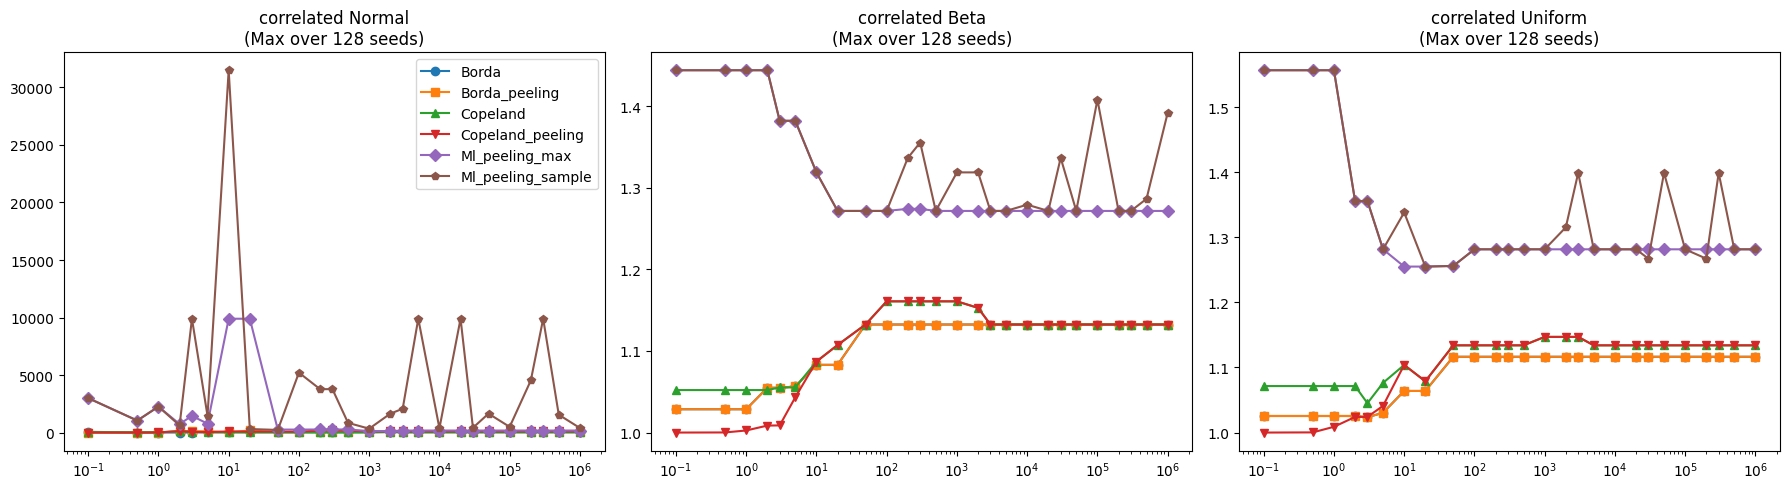

In [42]:
import concurrent.futures
from collections import defaultdict

n_voters = 30
m_candidates = 30
betas = [0.1, 0.5, 1.0, 2.0, 3.0, 5.0, 10.0, 20.0, 50.0, 100.0, 200, 300, 500, 1000, 2000, 3000, 5000, 10000, 20000, 30000, 50000, 100000, 200000, 300000, 500000, 1e6]

n_samples_finite = None # Set to None for infinite limit
n_seeds = 128 # Number of times to run with different seeds
max_workers = 128 # Number of parallel threads/processes

methods_to_run = ['borda', 'borda_peeling', 'copeland', 'copeland_peeling', 'ml_peeling_max', 'ml_peeling_sample', 'ml_peeling_group', 'ml_peeling_expected']

def run_sim(utilities, method, n_samples=None, beta=1.0):
    voter_dist = np.ones(n_voters, dtype=float) / n_voters
    avg_utils = voter_dist @ utilities
    true_rank = np.argsort(-avg_utils)
    
    out = defaultdict(list)
    
    for b in betas:
        # Pass utilities and current beta so borda_correlated can compute its BT logic iteratively
        sampling_dist = SamplingDistribution(m_candidates, method=method, utilities=utilities, beta=b, voter_dist=voter_dist, S=1000, T=10, alpha=2.0, beta_param=5.0)

        P_inf = compute_win_rate_matrix(utilities, voter_dist, beta=b)
        P = sample_win_rate_matrix(P_inf, n_samples)
        
        borda_rank = borda_ranking(P, sampling_dist)
        peel_rank = borda_peeling(P_inf, sampling_dist, n_samples)
        cope_rank = copeland_ranking(P, sampling_dist)
        cope_peel = copeland_peeling(P_inf, sampling_dist, n_samples)
        
        try:
            ml_p_max = maximal_lottery_peeling_max(P_inf, sampling_dist, n_samples)
            ml_dist_pmax = compute_supremum_leaderboard_distortion(ml_p_max, true_rank, avg_utils)
        except Exception:
            ml_dist_pmax = float('nan')
        out['ml_peeling_max'].append(ml_dist_pmax)

        try:
            ml_p_samp = maximal_lottery_peeling_sample(P_inf, sampling_dist, n_samples)
            ml_dist_psamp = compute_supremum_leaderboard_distortion(ml_p_samp, true_rank, avg_utils)
        except Exception:
            ml_dist_psamp = float('nan')
        out['ml_peeling_sample'].append(ml_dist_psamp)

        out['borda'].append(compute_supremum_leaderboard_distortion(borda_rank, true_rank, avg_utils))
        out['borda_peeling'].append(compute_supremum_leaderboard_distortion(peel_rank, true_rank, avg_utils))
        out['copeland'].append(compute_supremum_leaderboard_distortion(cope_rank, true_rank, avg_utils))
        out['copeland_peeling'].append(compute_supremum_leaderboard_distortion(cope_peel, true_rank, avg_utils))
        
    return out

def run_single_seed(seed):
    dist_normal = sample_utilities_normal(n_voters, m_candidates, seed=seed)
    dist_beta = sample_utilities_beta(n_voters, m_candidates, a=2, b=5, seed=seed)
    dist_unif = sample_utilities_0_1(n_voters, m_candidates, seed=seed)
    
    # We can invoke varying methods (like borda_correlated) here by replacing the method argument:
    current_method = "basic_correlated"
    
    out_ind_norm = run_sim(dist_normal, current_method, n_samples_finite)
    out_ind_beta = run_sim(dist_beta, current_method, n_samples_finite)
    out_ind_unif = run_sim(dist_unif, current_method, n_samples_finite)
    
    return {
        "correlated_normal": out_ind_norm,
        "correlated_beta": out_ind_beta,
        "correlated_uniform": out_ind_unif
    }

def aggregate_results(seed_results):
    all_runs = {
        dist: {m: [] for m in methods_to_run} 
        for dist in ["correlated_normal", "correlated_beta", "correlated_uniform"]
    }
    
    for res in seed_results:
        for dist, out_dict in res.items():
            for m in methods_to_run:
                all_runs[dist][m].append(out_dict[m])

    results = {}
    for dist in all_runs:
        for m in methods_to_run:
            results[f"{dist}_{m}"] = np.nanmax(all_runs[dist][m], axis=0)
            
    return results

def plot_results(results):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    labels = methods_to_run
    markers = ['o', 's', '^', 'v', 'D', 'p', 'x']

    dist_names = ["correlated_normal", "correlated_beta", "correlated_uniform"]
    titles = ["correlated Normal", "correlated Beta", "correlated Uniform"]

    for i, (d_name, title) in enumerate(zip(dist_names, titles)):
        for j, m in enumerate(labels):
            axes[i].plot(betas, results[f"{d_name}_{m}"], marker=markers[j], label=m.capitalize())
        axes[i].set_title(f"{title}\n(Max over {n_seeds} seeds)")
        axes[i].set_xscale("log")
        if i == 0:
            axes[i].legend()

    plt.tight_layout()
    plt.show()

# Run simulations in parallel
print(f"Running simulations for {n_seeds} seeds using {max_workers} processes...")
with concurrent.futures.ProcessPoolExecutor(max_workers=max_workers) as executor:
    seed_results = list(executor.map(run_single_seed, range(n_seeds)))

print("Aggregating and plotting results...")
results = aggregate_results(seed_results)
plot_results(results)



# 10. Correlated Beta - WIP

Running simulations for 128 seeds using 128 processes...
Aggregating and plotting results...


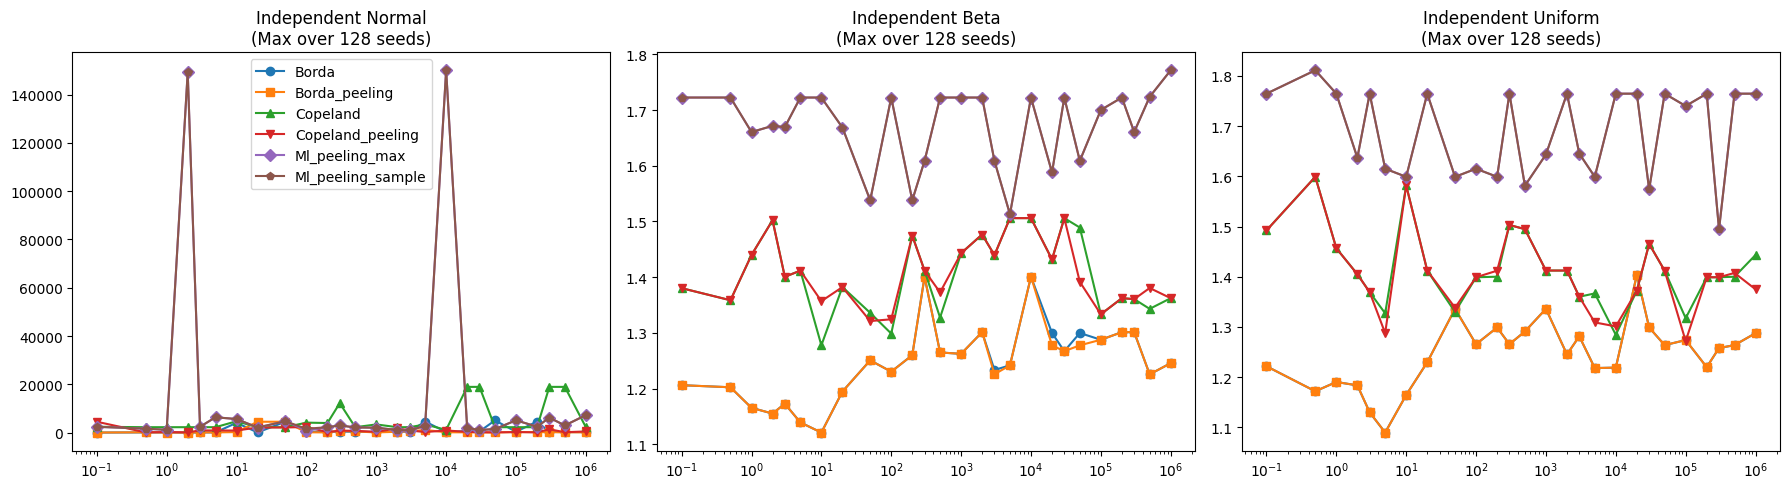

In [ ]:
import concurrent.futures
from collections import defaultdict

n_voters = 30
m_candidates = 30
betas = [0.1, 0.5, 1.0, 2.0, 3.0, 5.0, 10.0, 20.0, 50.0, 100.0, 200, 300, 500, 1000, 2000, 3000, 5000, 10000, 20000, 30000, 50000, 100000, 200000, 300000, 500000, 1e6]

n_samples_finite = None # Set to None for infinite limit
n_seeds = 128 # Number of times to run with different seeds
max_workers = 128 # Number of parallel threads/processes

methods_to_run = ['borda', 'borda_peeling', 'copeland', 'copeland_peeling', 'ml_peeling_max', 'ml_peeling_sample', 'ml_peeling_group', 'ml_peeling_expected']

def run_sim(utilities, method, n_samples=None, beta=1.0):
    voter_dist = np.ones(n_voters, dtype=float) / n_voters
    avg_utils = voter_dist @ utilities
    true_rank = np.argsort(-avg_utils)
    
    out = defaultdict(list)
    
    for b in betas:
        # Pass utilities and current beta so borda_correlated can compute its BT logic iteratively
        sampling_dist = SamplingDistribution(m_candidates, method=method, utilities=utilities, beta=b, voter_dist=voter_dist, S=1000, T=10, alpha=2.0, beta_param=5.0)

        P_inf = compute_win_rate_matrix(utilities, voter_dist, beta=b)
        P = sample_win_rate_matrix(P_inf, n_samples)
        
        borda_rank = borda_ranking(P, sampling_dist)
        peel_rank = borda_peeling(P_inf, sampling_dist, n_samples)
        cope_rank = copeland_ranking(P, sampling_dist)
        cope_peel = copeland_peeling(P_inf, sampling_dist, n_samples)
        
        try:
            ml_p_max = maximal_lottery_peeling_max(P_inf, sampling_dist, n_samples)
            ml_dist_pmax = compute_supremum_leaderboard_distortion(ml_p_max, true_rank, avg_utils)
        except Exception:
            ml_dist_pmax = float('nan')
        out['ml_peeling_max'].append(ml_dist_pmax)

        try:
            ml_p_samp = maximal_lottery_peeling_sample(P_inf, sampling_dist, n_samples)
            ml_dist_psamp = compute_supremum_leaderboard_distortion(ml_p_samp, true_rank, avg_utils)
        except Exception:
            ml_dist_psamp = float('nan')
        out['ml_peeling_sample'].append(ml_dist_psamp)

        out['borda'].append(compute_supremum_leaderboard_distortion(borda_rank, true_rank, avg_utils))
        out['borda_peeling'].append(compute_supremum_leaderboard_distortion(peel_rank, true_rank, avg_utils))
        out['copeland'].append(compute_supremum_leaderboard_distortion(cope_rank, true_rank, avg_utils))
        out['copeland_peeling'].append(compute_supremum_leaderboard_distortion(cope_peel, true_rank, avg_utils))
        
    return out

def run_single_seed(seed):
    dist_normal = sample_utilities_normal(n_voters, m_candidates, seed=seed)
    dist_beta = sample_utilities_beta(n_voters, m_candidates, a=2, b=5, seed=seed)
    dist_unif = sample_utilities_0_1(n_voters, m_candidates, seed=seed)
    
    # We can invoke varying methods (like borda_correlated) here by replacing the method argument:
    current_method = "borda_correlated"
    
    out_ind_norm = run_sim(dist_normal, current_method, n_samples_finite)
    out_ind_beta = run_sim(dist_beta, current_method, n_samples_finite)
    out_ind_unif = run_sim(dist_unif, current_method, n_samples_finite)
    
    return {
        "correlated_normal": out_ind_norm,
        "correlated_beta": out_ind_beta,
        "correlated_uniform": out_ind_unif
    }

def aggregate_results(seed_results):
    all_runs = {
        dist: {m: [] for m in methods_to_run} 
        for dist in ["correlated_normal", "correlated_beta", "correlated_uniform"]
    }
    
    for res in seed_results:
        for dist, out_dict in res.items():
            for m in methods_to_run:
                all_runs[dist][m].append(out_dict[m])

    results = {}
    for dist in all_runs:
        for m in methods_to_run:
            results[f"{dist}_{m}"] = np.nanmax(all_runs[dist][m], axis=0)
            
    return results

def plot_results(results):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    labels = methods_to_run
    markers = ['o', 's', '^', 'v', 'D', 'p', 'x']

    dist_names = ["correlated_normal", "correlated_beta", "correlated_uniform"]
    titles = ["correlated Normal", "correlated Beta", "correlated Uniform"]

    for i, (d_name, title) in enumerate(zip(dist_names, titles)):
        for j, m in enumerate(labels):
            axes[i].plot(betas, results[f"{d_name}_{m}"], marker=markers[j], label=m.capitalize())
        axes[i].set_title(f"{title}\n(Max over {n_seeds} seeds)")
        axes[i].set_xscale("log")
        if i == 0:
            axes[i].legend()

    plt.tight_layout()
    plt.show()

# Run simulations in parallel
print(f"Running simulations for {n_seeds} seeds using {max_workers} processes...")
with concurrent.futures.ProcessPoolExecutor(max_workers=max_workers) as executor:
    seed_results = list(executor.map(run_single_seed, range(n_seeds)))

print("Aggregating and plotting results...")
results = aggregate_results(seed_results)
plot_results(results)



In [20]:
def compare_leaderboards(rank1, rank2):
    """
    Compares two leaderboards (rankings) and returns the Kendall tau distance
    (number of pairwise disagreements) along with exactly matching positions.
    """
    from scipy.stats import kendalltau
    tau, p_value = kendalltau(rank1, rank2)
    
    # Exact positional matches
    exact_matches = np.sum(np.asarray(rank1) == np.asarray(rank2))
    
    # Kendall tau distance = (1 - tau) / 2 mapped to number of pairs
    # Wait, usually tau ranges from -1 to 1. 
    # tau = (concordant - discordant) / total_pairs
    # Total pairs = n*(n-1)/2
    n = len(rank1)
    total_pairs = n * (n - 1) / 2
    discordant_pairs = round((1 - tau) / 2 * total_pairs) if not np.isnan(tau) else float('nan')
    
    return {
        "kendall_tau": tau,
        "discordant_pairs": discordant_pairs,
        "exact_matches": exact_matches,
        "total_elements": n
    }

# Example usage: comparing borda and copeland worst case leaderboards on uniform, for the 3rd beta:
r1 = worst_case_rankings['independent_uniform_borda'][0]
r2 = worst_case_rankings['independent_uniform_borda_peeling'][0]
print(compare_leaderboards(r1, r2))

{'kendall_tau': np.float64(1.0), 'discordant_pairs': 0, 'exact_matches': np.int64(30), 'total_elements': 30}


In [22]:
taus = []
for r1, r2 in zip(worst_case_rankings['independent_uniform_borda'], worst_case_rankings['independent_uniform_borda_peeling']):
    if r1 is not None and r2 is not None:
        result = compare_leaderboards(r1, r2)
        taus.append(result['kendall_tau'])


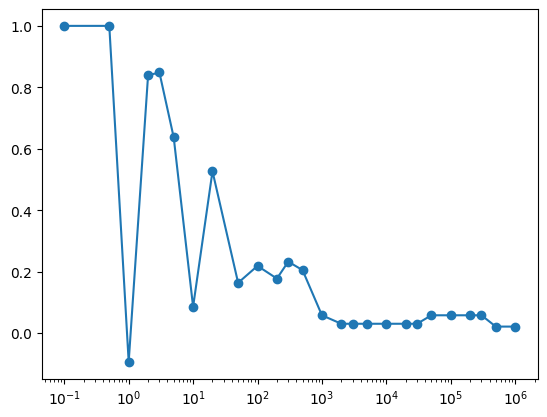

In [24]:
plt.plot(betas, taus, marker='o')
plt.xscale('log')

In [14]:
r1

array([28, 14,  2, 12, 21,  0, 13,  5, 25, 27, 17, 23, 11, 15, 18, 24,  3,
       26, 29,  4, 10, 22, 16, 20, 19,  9,  7,  8,  1,  6])

In [16]:
r2

array([18, 17,  6, 29, 22, 10, 25,  7,  4, 20, 27, 16, 11,  1, 23, 15, 26,
        9,  0, 24, 28,  2, 14,  3, 21,  5, 13,  8, 12, 19])

In [18]:
 worst_case_rankings['independent_uniform_borda']

[array([21,  9,  0, 26, 12, 25, 20, 27,  1,  8, 24,  6, 15,  3, 14, 29, 19,
        16, 23, 18,  2,  4,  5, 10, 28, 22,  7, 17, 11, 13]),
 array([19,  5,  8, 29, 26, 22,  6, 18, 20, 23,  2,  3, 14,  4, 21,  9, 11,
        25, 15, 17,  7,  0, 28, 10, 24, 12, 27,  1, 16, 13]),
 array([28, 14,  2, 12, 21,  0, 13,  5, 25, 27, 17, 23, 11, 15, 18, 24,  3,
        26, 29,  4, 10, 22, 16, 20, 19,  9,  7,  8,  1,  6]),
 array([24, 23, 10, 15, 17, 13, 11, 26, 25, 21,  5,  8, 28, 27,  7,  1, 20,
        12, 19, 14,  9,  6,  3, 22,  4, 18, 29, 16,  2,  0]),
 array([26,  3, 14, 10, 13,  0, 22, 11,  8,  7, 29, 15, 21,  9, 19,  2, 20,
        23,  5,  4, 25, 18, 16, 27, 17,  6, 24, 28, 12,  1]),
 array([21,  4, 23, 26,  6, 14,  8, 18, 28, 29,  0,  1,  5,  2,  7, 19, 15,
        16, 11, 24, 17, 13, 20, 12, 10, 25, 27,  3, 22,  9]),
 array([21,  4, 14, 26,  6, 23, 18,  8, 28,  0, 29,  1,  2,  5,  7, 19, 15,
        16, 24, 11, 13, 17, 20, 12, 10, 25, 27,  3, 22,  9]),
 array([15, 13, 26, 19,  6, 16, 14

In [19]:
 worst_case_rankings['independent_uniform_borda_peeling']

[array([21,  9,  0, 26, 12, 25, 20, 27,  1,  8, 24,  6, 15,  3, 14, 29, 19,
        16, 23, 18,  2,  4,  5, 10, 28, 22,  7, 17, 11, 13]),
 array([19,  5,  8, 29, 26, 22,  6, 18, 20, 23,  2,  3, 14,  4, 21,  9, 11,
        25, 15, 17,  7,  0, 28, 10, 24, 12, 27,  1, 16, 13]),
 array([18, 17,  6, 29, 22, 10, 25,  7,  4, 20, 27, 16, 11,  1, 23, 15, 26,
         9,  0, 24, 28,  2, 14,  3, 21,  5, 13,  8, 12, 19]),
 array([24, 23, 10, 15, 17, 13, 11, 26, 25, 21,  5,  8, 28, 27,  1,  7, 20,
        12, 19, 14,  6,  9,  3, 22,  4, 29, 18, 16,  2,  0]),
 array([26,  3, 14, 10, 13,  0, 22,  8, 11,  7, 29, 15,  9, 21, 19,  2, 20,
        23,  5,  4, 25, 18, 16, 27, 17,  6, 28, 24, 12,  1]),
 array([21,  4, 23,  6, 26, 14,  8, 18, 28, 29,  0,  1,  5,  2,  7, 19, 15,
        11, 16, 24, 13, 17, 20, 10, 25, 12, 27,  3, 22,  9]),
 array([21,  4,  6, 14, 26, 23,  8, 18, 28, 29,  0,  1,  2,  5, 19,  7, 15,
        11, 24, 13, 16, 17, 10, 12, 20, 25,  3, 27, 22,  9]),
 array([15, 13, 26, 19,  6, 16, 14